               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

C:\Users\Mohamed liyakath ali\AppData\Local\Temp\ipykernel_13076\4090157697.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


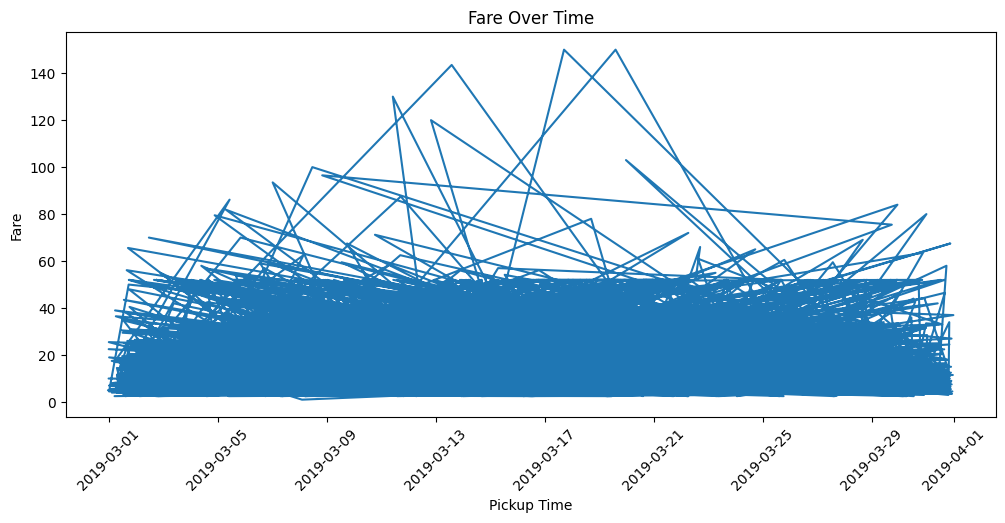

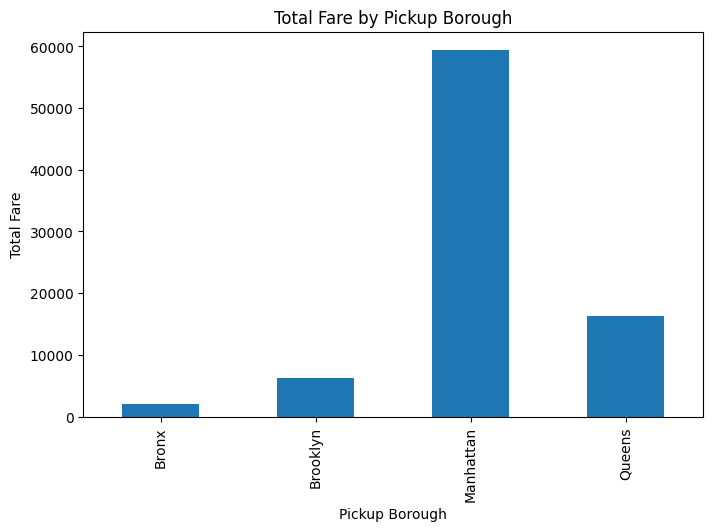

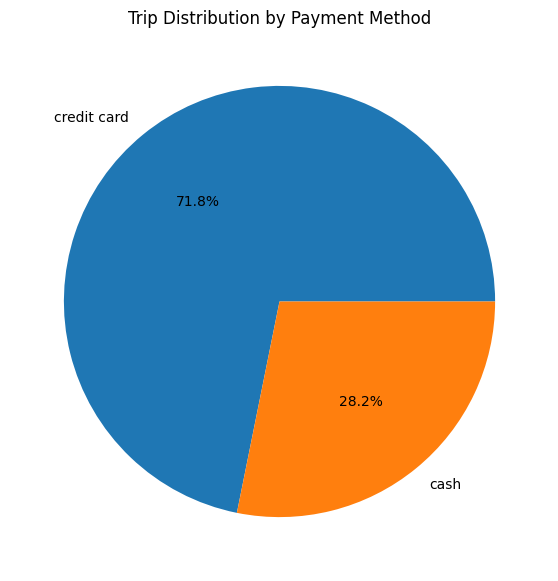

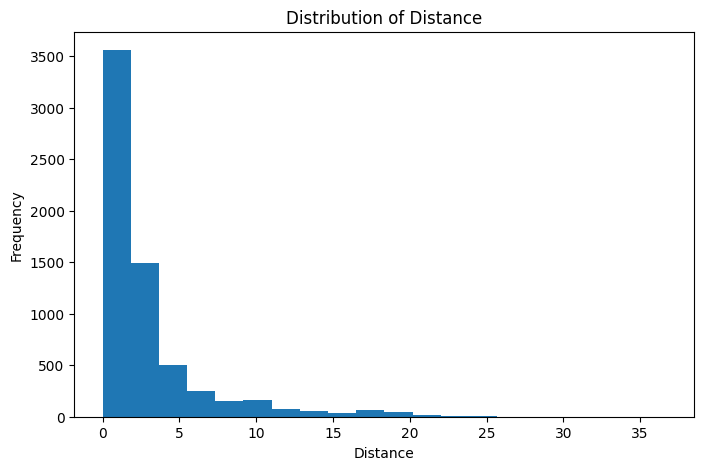

C:\Users\Mohamed liyakath ali\AppData\Local\Temp\ipykernel_13076\4090157697.py:131: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


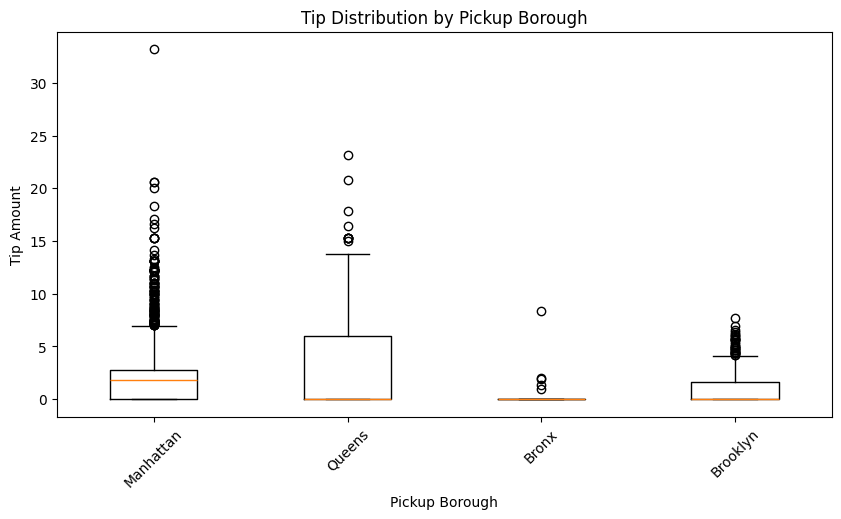

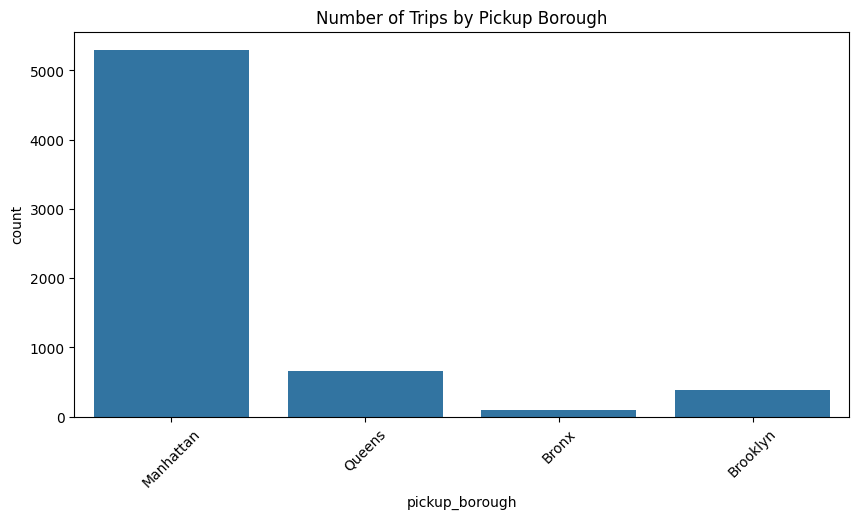

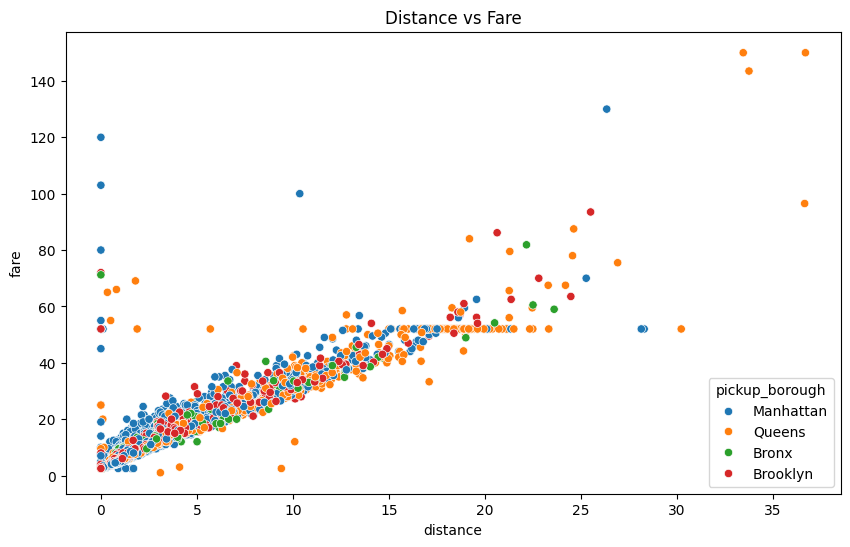

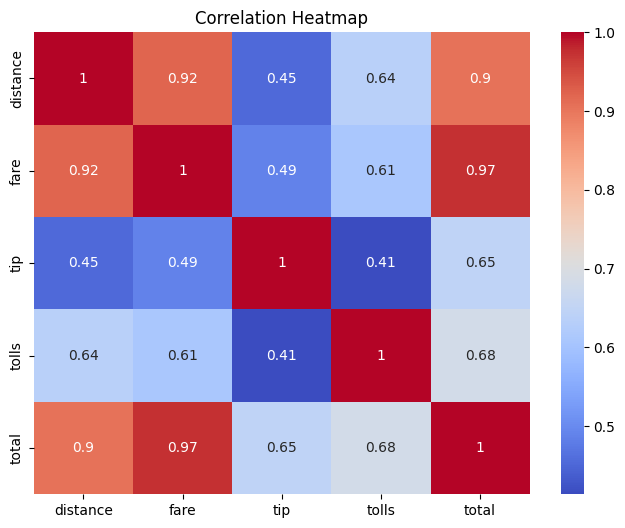

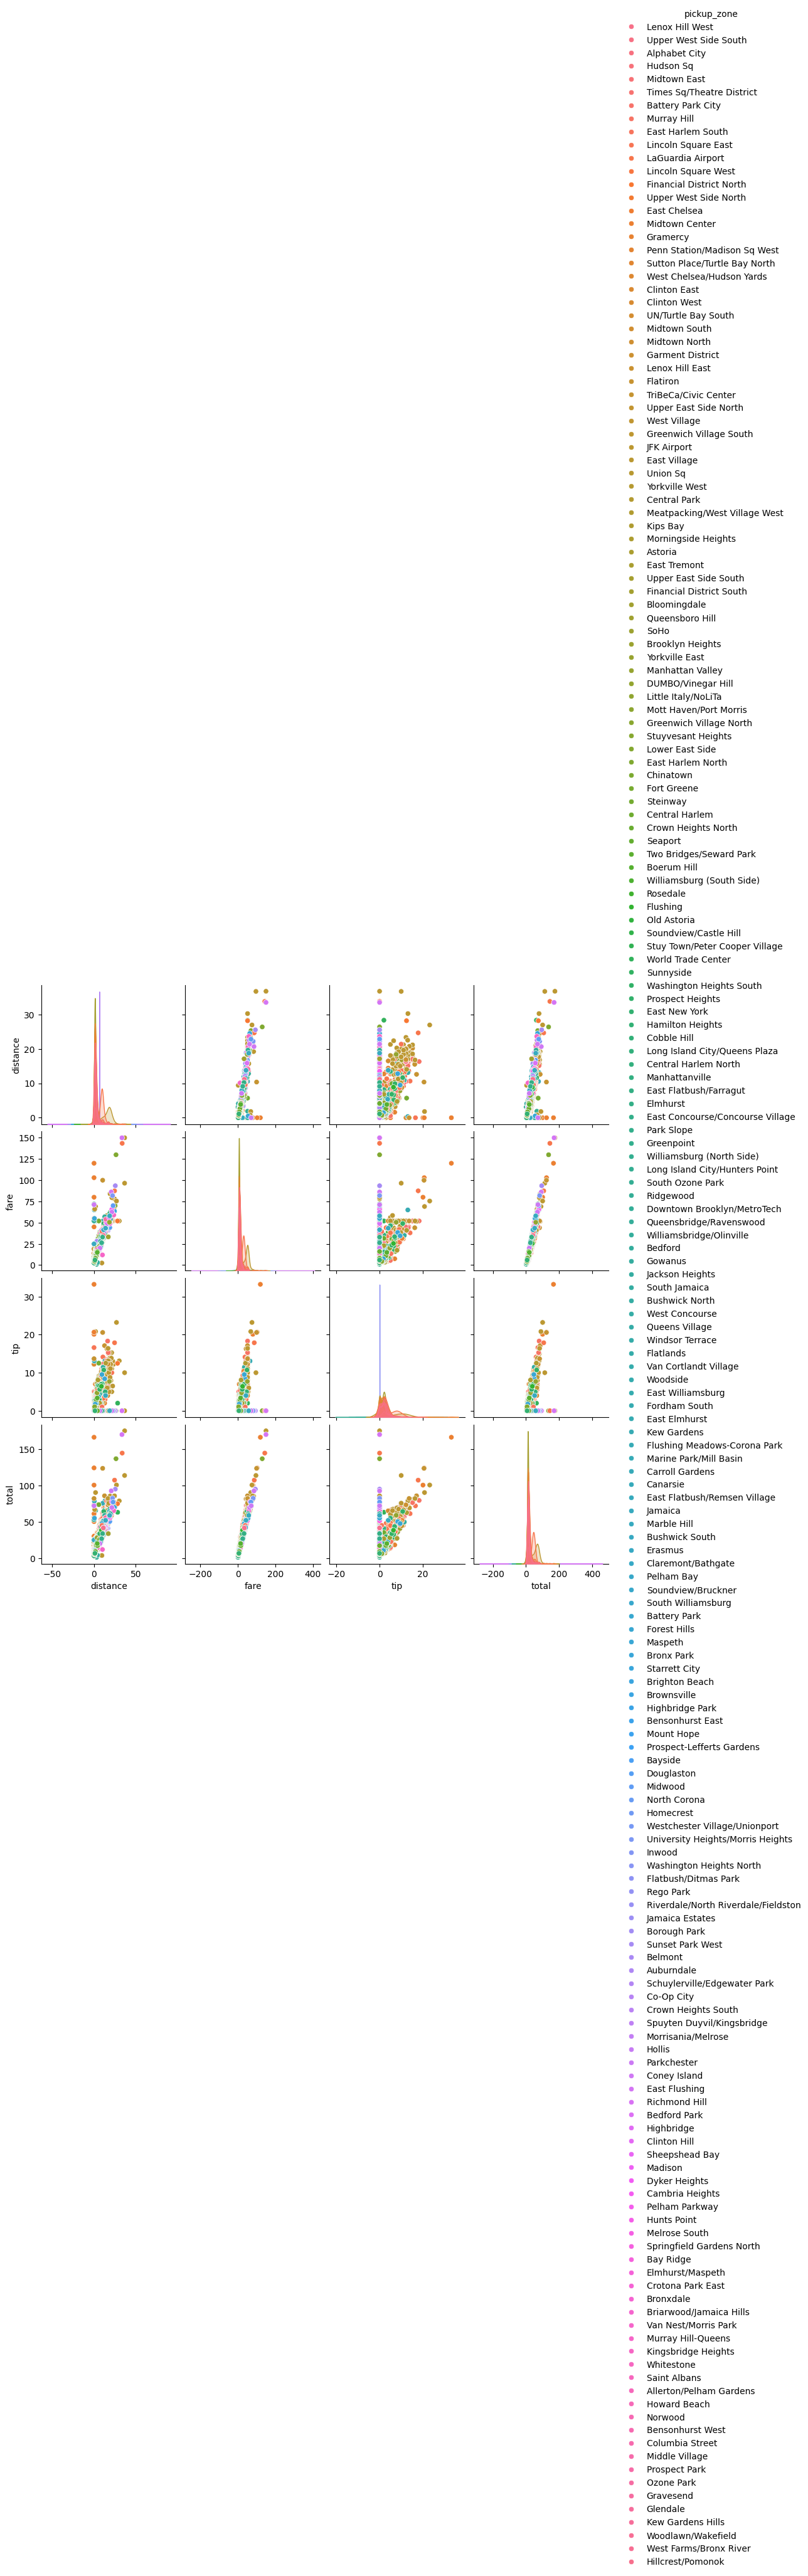

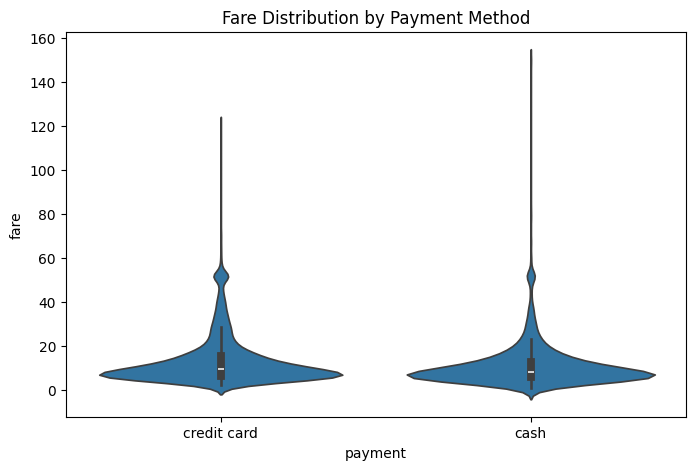

In [1]:
# =========================================
# Taxi Data Analysis and Visualization
# =========================================

# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================
# 1. Load Dataset
# =========================================

# Load the taxis dataset
df = sns.load_dataset("taxis")

# Display first 5 rows
print(df.head())

# Dataset information
print(df.info())

# =========================================
# 2. Handling Missing Values
# =========================================

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------------------
# Impute Numerical Columns
# -----------------------------------------

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# -----------------------------------------
# Impute Categorical Columns
# -----------------------------------------

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# -----------------------------------------
# Remove Remaining Missing Values
# -----------------------------------------

df = df.dropna()

# Verify Missing Values Again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# =========================================
# Convert pickup column to datetime
# =========================================

df["pickup"] = pd.to_datetime(df["pickup"])

# =========================================
# 3. Visualizations using Matplotlib/Pandas
# =========================================

# -----------------------------------------
# LINE CHART
# Fare over time
# -----------------------------------------

plt.figure(figsize=(12,5))
plt.plot(df["pickup"], df["fare"])
plt.title("Fare Over Time")
plt.xlabel("Pickup Time")
plt.ylabel("Fare")
plt.xticks(rotation=45)
plt.show()

# -----------------------------------------
# BAR CHART
# Total fare by pickup_borough
# -----------------------------------------

borough_fare = df.groupby("pickup_borough")["fare"].sum()

borough_fare.plot(kind="bar", figsize=(8,5))
plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.show()

# -----------------------------------------
# PIE CHART
# Payment method distribution
# -----------------------------------------

payment_counts = df["payment"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Trip Distribution by Payment Method")
plt.show()

# -----------------------------------------
# HISTOGRAM
# Distribution of distance
# -----------------------------------------

plt.figure(figsize=(8,5))
plt.hist(df["distance"], bins=20)
plt.title("Distribution of Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

# -----------------------------------------
# BOX PLOT
# Tip distribution by pickup_borough
# -----------------------------------------

plt.figure(figsize=(10,5))
plt.boxplot(
    [df[df["pickup_borough"] == b]["tip"] for b in df["pickup_borough"].unique()],
    labels=df["pickup_borough"].unique()
)

plt.title("Tip Distribution by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")
plt.xticks(rotation=45)
plt.show()

# =========================================
# 4. Visualizations using Seaborn
# =========================================

# -----------------------------------------
# COUNT PLOT
# Trips count by pickup_borough
# -----------------------------------------

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="pickup_borough")

plt.title("Number of Trips by Pickup Borough")
plt.xticks(rotation=45)
plt.show()

# -----------------------------------------
# SCATTER PLOT
# Distance vs Fare
# -----------------------------------------

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="distance",
    y="fare",
    hue="pickup_borough"
)

plt.title("Distance vs Fare")
plt.show()

# -----------------------------------------
# HEATMAP
# Correlation between numerical variables
# -----------------------------------------

corr = df[["distance", "fare", "tip", "tolls", "total"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

# -----------------------------------------
# PAIR PLOT
# Pairwise relationships
# -----------------------------------------

sns.pairplot(
    df,
    vars=["distance", "fare", "tip", "total"],
    hue="pickup_zone"
)

plt.show()

# -----------------------------------------
# VIOLIN PLOT
# Fare distribution by payment method
# -----------------------------------------

plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x="payment",
    y="fare"
)

plt.title("Fare Distribution by Payment Method")
plt.show()